In [ ]:
# pip install kaggle

In [ ]:
!mkdir ~/.kaggle

!cp kaggle.json ~/.kaggle/

!chmod 600 ~/.kaggle/kaggle.json

mkdir: cannot create directory ‘/root/.kaggle’: File exists
cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [ ]:
!kaggle datasets download -d salader/dogsvscats

Dataset URL: https://www.kaggle.com/datasets/salader/dogsvscats
License(s): unknown
dogsvscats.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
!unzip dataset-name.zip

unzip:  cannot find or open dataset-name.zip, dataset-name.zip.zip or dataset-name.zip.ZIP.


In [ ]:
import zipfile
zip_ref = zipfile.ZipFile("/content/dogsvscats.zip")
zip_ref.extractall("/content")
zip_ref.close()

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense , Conv2D , MaxPooling2D , Flatten , BatchNormalization , Dropout

In [ ]:
# Generators for process the image because it process iamge in batch form so that it not occupeid RAM memory

train_ds = keras.utils.image_dataset_from_directory(
    directory = '/content/train' ,
    labels = 'inferred' ,
    label_mode = 'int' ,
    batch_size = 32 ,
    image_size = (256 , 256)
)

Found 20000 files belonging to 2 classes.


In [ ]:
validation_ds = keras.utils.image_dataset_from_directory(
    directory = '/content/test' ,
    labels = 'inferred' ,
    label_mode = 'int' ,
    batch_size = 32 ,
    image_size = (256 , 256)
)

Found 5000 files belonging to 2 classes.


In [ ]:
def image_process(image , label) :
  image = tf.cast(image/255 , tf.float32)
  return image , label

train_ds = train_ds.map(image_process)
validation_ds = validation_ds.map(image_process)

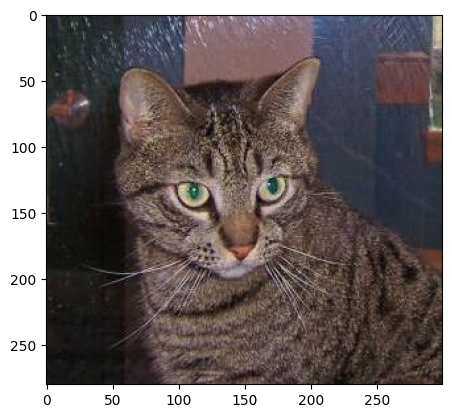

In [ ]:
import matplotlib.pyplot as plt

image = tf.keras.utils.load_img("/content/train/cats/cat.1.jpg")

plt.imshow(image)
plt.show()

In [ ]:
## Create cnn model

model = Sequential()


model.add(Conv2D(32 , kernel_size = (3 ,3 ) , padding='valid' , activation='relu' , input_shape=( 256 , 256 , 3)))
model.add(MaxPooling2D(pool_size=(2 ,2 ) , strides = 2 , padding='valid'))

model.add(Conv2D(64 , kernel_size=(3,3) , padding='valid' , activation='relu'))
model.add(MaxPooling2D(pool_size=(2 ,2 ) , strides=2 , padding='valid'))


model.add(Conv2D(128 , kernel_size=(3,3) , padding='valid' , activation='relu'))
model.add(MaxPooling2D(pool_size=(2 ,2 ) , strides=2 , padding='valid'))

model.add(Flatten())

model.add(Dense(64 , activation='relu' ))
model.add(Dropout(0.1))

model.add(Dense(32 , activation='relu'))
model.add(Dropout(0.1))

model.add(Dense(1 , activation='sigmoid'))

In [ ]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │     7,372,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,468,225 (28.49 MB)

 Trainable params: 7,468,225 (28.49 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam' , loss='binary_crossentropy' , metrics=['accuracy'])

In [ ]:
model.fit(train_ds , epochs=5 , validation_data=validation_ds)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 59s 77ms/step - accuracy: 0.6024 - loss: 0.6570 - val_accuracy: 0.7076 - val_loss: 0.5708
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 47s 74ms/step - accuracy: 0.7222 - loss: 0.5454 - val_accuracy: 0.7614 - val_loss: 0.4931
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 50s 80ms/step - accuracy: 0.7846 - loss: 0.4612 - val_accuracy: 0.7634 - val_loss: 0.4970
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 79s 74ms/step - accuracy: 0.8300 - loss: 0.3857 - val_accuracy: 0.7934 - val_loss: 0.4591
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 45s 73ms/step - accuracy: 0.8676 - loss: 0.3017 - val_accuracy: 0.7760 - val_loss: 0.5029


In [41]:
model.save("cnn_model.keras")

In [101]:
from tensorflow.keras.preprocessing import image
import numpy as np
import joblib

img = image.load_img('/content/ img c.jpeg',
    target_size=(256, 256))

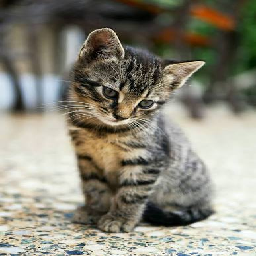

In [102]:
img

In [103]:
img_array = image.img_to_array(img)

In [104]:
# image = image / 255
img_array = img_array / 255.0

In [110]:
img_array = np.expand_dims(img_array, axis=0)

In [106]:
img_array.shape

(1, 256, 256, 3)

In [107]:
prediction = model.predict(img_array)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


In [108]:
probability = prediction[0][0]

probability

np.float32(0.0062995334)

In [109]:
if probability > 0.5:
    print("Dog")
else:
    print("Cat")

print("Probability:" , probability)

Cat
Probability: 0.0062995334


In [112]:
import os

class_names = sorted(os.listdir("/content/train"))

print(class_names)

['cats', 'dogs']


In [114]:
import joblib

joblib.dump(class_names, "class_names.pkl")

['class_names.pkl']